In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
d2h = pd.read_csv("Data_transfer_D2H_miro.txt", 
                 delim_whitespace=True,
                    comment='M',
                 skiprows=1, 
                 names=["data", "time", "transfer"])
d2h["transfer"] = d2h["transfer"] / 1e9

h2d = pd.read_csv("Data_transfer_H2D_miro.txt", 
                 delim_whitespace=True,
                  comment='M',
                 skiprows=1, 
                 names=["data", "time", "transfer"])
h2d["transfer"] = h2d["transfer"] / 1e9

d2d = pd.read_csv("Data_transfer_D2D_miro.txt", 
                 delim_whitespace=True,
                 skiprows=1, 
                 names=["data", "time", "transfer"])
d2d["transfer"] = d2d["transfer"] / 1e9


/tmp/ipykernel_1809164/1143504399.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  d2h = pd.read_csv("Data_transfer_D2H_miro.txt",
/tmp/ipykernel_1809164/1143504399.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  h2d = pd.read_csv("Data_transfer_H2D_miro.txt",
/tmp/ipykernel_1809164/1143504399.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  d2d = pd.read_csv("Data_transfer_D2D_miro.txt",


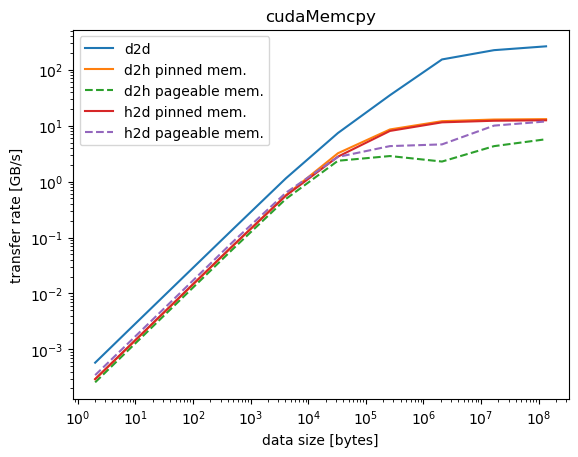

In [17]:
plt.plot(d2d['data'], d2d['transfer'], label='d2d')
plt.plot(d2h['data'][10:], d2h['transfer'][10:], label='d2h pinned mem.')
plt.plot(d2h['data'][:10], d2h['transfer'][:10], '--', label='d2h pageable mem.')
plt.plot(h2d['data'][10:], h2d['transfer'][10:], label='h2d pinned mem.')
plt.plot(h2d['data'][:10], h2d['transfer'][:10], '--', label='h2d pageable mem.')


plt.xscale('log')
plt.yscale('log')
plt.title('cudaMemcpy')
plt.xlabel('data size [bytes]')
plt.ylabel('transfer rate [GB/s]')
plt.legend()
plt.savefig('cudaMemcpy.pdf')
plt.show()

In [28]:
d2d_threads = pd.read_csv("coalesced_memory_access_results.txt", 
                         delimiter=",",
                         skiprows=1, 
                         names=["data", "threads", "transfer"])

In [31]:
d2d_threads["transfer"]

0      0.040998
1      0.046228
2      0.045883
3      0.049241
4      0.045136
        ...    
61     0.976857
62     1.939356
63     3.830359
64     7.448761
65    13.902481
Name: transfer, Length: 66, dtype: float64

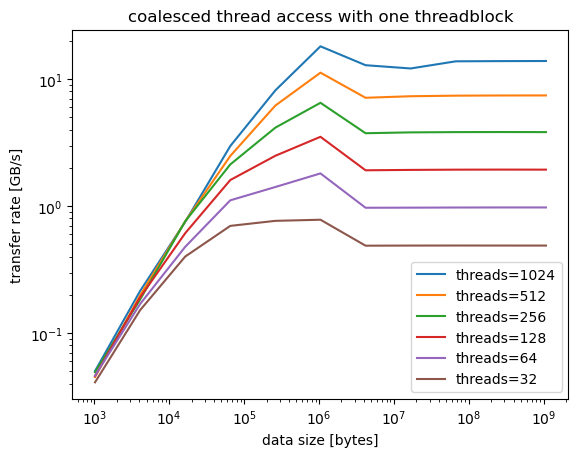

In [35]:
for threads_val in sorted(d2d_threads['threads'].unique(), reverse=True):
    subset = d2d_threads[d2d_threads['threads'] == threads_val]
    plt.plot(subset['data'], subset['transfer'], label=f"threads={int(threads_val)}")

plt.xscale('log')
plt.yscale('log')
plt.xlabel('data size [bytes]')
plt.ylabel('transfer rate [GB/s]')
plt.title('coalesced thread access with one threadblock')
plt.legend()
plt.savefig('coalesced_trhead_access_a.pdf')
plt.show()